### LFC REG

In [114]:
# Standard library imports
from re import A
import sys
import os
import random
from typing import Literal, Optional
from src.dataops.pseudobulk import create_pseudobulk
# Third-party imports
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy.sparse import csr_matrix

# Configuration
torch.set_float32_matmul_precision('high')

# Local imports
from src.dataops.data_utils import extract
from src.metrics.dge import run_dge


from src.utils.constants import IBD_PATH, IBD_PROMPTS5, IBD_METADATA_NAMES, IBD_PROMPTS, IBD_PROMPTS2


# Helper function
to_array = lambda matrix: matrix.toarray() if not isinstance(matrix, np.ndarray) else matrix

def dge(adata: ad.AnnData, 
        prompts: list[dict],
        lfc_cutoff: float = 0.6, 
        pval_cutoff: float = 0.05,
        sample_col: str = 'sample_id',
        mode: Literal['sum', 'mean'] = 'sum',
        n_max: int = None,
        pseudobulk: bool = True
        ) -> tuple[list[str], np.ndarray]:
    if pseudobulk:
        pb = create_pseudobulk(adata, sample_col = sample_col, mode = mode)
        print(pb)
    else:
        pb = adata
    extracted = [to_array(extract(pb, prompt, n_max).X) for prompt in prompts[1:]]
    _, _, _, lfc, _, genes = run_dge(extracted[-2], extracted[-1], lfc_cutoff, pval_cutoff, gene_list = adata.var_names.to_list())
    return genes, lfc
# Setup

model_name = 'CFGen'
sys.path.append('..')
data_path = IBD_PATH
metadata_names = IBD_METADATA_NAMES
prompts = IBD_PROMPTS
SEED = 42

In [115]:
prompt1 = prompts
prompt2 = prompts
print('prompt1  :', prompt1)
print('prompt2  :', prompt2)

from src.dataops.preprocess import preprocess_adata, PreprocessConfig

adata = ad.read_h5ad('data/datasets/cellarity_ibd_dataset_level_cleaned_norm.h5ad')
## Preprocess adata

preprocess_config = PreprocessConfig(gene_name_col = 'gene_symbols', only_keep_prompts = True, prompts = prompts)
adata = preprocess_adata(adata, metadata_names, preprocess_config)
adata

prompt1  : [{}, {'tissue_unified': 'mucosa of ascending colon', 'disease_colon': 'healthy'}, {'tissue_unified': 'mucosa of ascending colon', 'disease_colon': 'Crohn disease'}]
prompt2  : [{}, {'tissue_unified': 'mucosa of ascending colon', 'disease_colon': 'healthy'}, {'tissue_unified': 'mucosa of ascending colon', 'disease_colon': 'Crohn disease'}]

[X] Checked that all metadata names are in the adata object.
[X] Changed gene index to gene_symbols


AnnData object with n_obs × n_vars = 73858 × 1996
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'tissue', 'cell_line', 'data_source_id', 'experiment_type', 'data_type', 'sample_id', 'donor_id', 'source_sample_id', 'sample_GSM', 'cell_enrichment_type', 'cell_enrichment', 'genotype', 'mouse_strain', 'model', 'disease', 'disease_status', 'treat', 'dose', 'dose_unit', 'time', 'time_unit', 'sex', 'bmi', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'shannon_index', 'simpson_index', 'invsimpson_index', 'gini_index', 'mad_thresh', 'outlier_mad', 'scrublet.score', 'scrublet.class', 'scrublet_version', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'scDblFinder_version', 'hits', 'hits_weighted', 'min_dist',

In [ ]:
fake_adata = ad.read_h5ad('data/generated/scvi_generated_all.h5ad')
preprocess_config = PreprocessConfig(only_keep_prompts = True, prompts = prompts,)
fake_adata = preprocess_adata(fake_adata, metadata_names, preprocess_config)


[X] Checked that all metadata names are in the adata object.


In [117]:
fake_adata.obs
fake_adata

AnnData object with n_obs × n_vars = 76756 × 1996
    obs: 'tissue_unified', 'disease_colon', 'sample'

In [118]:
genes_real, lfc_real = dge(adata, prompts)


Pseudo bulking...
AnnData object with n_obs × n_vars = 7 × 1996
    obs: 'sample_id', 'sample', 'tissue', 'data_source_id', 'experiment_type', 'data_type', 'donor_id', 'source_sample_id', 'sample_GSM', 'cell_enrichment_type', 'disease', 'sex', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'mad_thresh', 'outlier_mad', 'scrublet.class', 'scrublet_version', 'scDblFinder.class', 'scDblFinder_version', 'tissue_unified', 'tissue_broad', 'disease_colon', 'disease_other', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'
Running DGE...
Time to run DGE 3.8264710903167725 seconds
3 upregulated genes 10 downregulated genes 1983 insignificant genes


In [119]:
print(genes_real)
print(lfc_real.shape)
print(genes_real.keys())

{'up': ['RNU1-1', 'INMT', 'CTSF'], 'down': ['IGKV1-8', 'IGKV3D-11', 'BICC1', 'FLT1', 'MEDAG', 'DCLK1', 'LHFPL6', 'TNFSF11', 'MEF2B', 'MT-TE']}
(1996,)
dict_keys(['up', 'down'])


In [120]:
genes_fake, lfc_fake = dge(fake_adata, prompts, sample_col = 'sample')

Pseudo bulking...
AnnData object with n_obs × n_vars = 7 × 1996
    obs: 'sample', 'tissue_unified', 'disease_colon', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'
Running DGE...
Time to run DGE 1.1079480648040771 seconds
65 upregulated genes 47 downregulated genes 1884 insignificant genes


In [121]:
print(genes_fake)
print(len(lfc_fake))

{'up': ['RNU1-1', 'AQP10', 'PRRX1', 'CFH', 'GPR25', 'KHK', 'NRXN1', 'IGKV1-17', 'IGKV2D-40', 'IGKV1D-22', 'IGKV1D-42', 'KYNU', 'ITPRID2', 'ABI3BP', 'C3orf85', 'SST', 'CFI', 'ENPEP', 'THBS4', 'DPYSL3', 'PTTG1', 'UBD', 'SOSTDC1', 'INMT', 'AQP1', 'TRGV10', 'AEBP1', 'IGFBP1', 'IGFBP3', 'GNG11', 'MUC3A', 'PTN', 'MUC5B', 'MUC15', 'VEGFB', 'CTSF', 'CLEC7A', 'HSPB8', 'SCEL', 'TRAV19', 'TRAV25', 'TRAV30', 'CRISPLD2', 'CLEC10A', 'KDM6B', 'TMEM88', 'AURKB', 'AC107982.1', 'RPS2P46', 'CCL15', 'CR936218.1', 'PECAM1', 'OTOP2', 'ENPP7', 'NFIC', 'LSR', 'AXL', 'APOC1', 'IL4I1', 'ATF5', 'LILRB5', 'SLC5A1', 'FHL1', 'BGN', 'AC134879.2'], 'down': ['AKR7A3', 'AC241584.1', 'RNU1-59P', 'AL359834.1', 'IGKV1-8', 'IGKV1D-33', 'IGKV2D-30', 'IGKV3D-11', 'GALNT5', 'SLC40A1', 'TM4SF1', 'S100P', 'SLC4A4', 'CCNB1', 'HMMR', 'HIST1H2BF', 'SMPDL3A', 'HEPACAM2', 'PRXL2A', 'CD248', 'LAG3', 'CD163L1', 'KLRC1', 'RIMBP2', 'FLT1', 'MEDAG', 'DCLK1', 'POSTN', 'LHFPL6', 'TNFSF11', 'AL138963.3', 'CNMD', 'PCDH17', 'KCTD12', 'TRAV24'

In [122]:
from src.metrics.dge import dges_precision_recall
dges_precision_recall(genes_real['up'], genes_real['down'], 1996, genes_fake['up'], genes_fake['down'])



{'tpr_up': 1.0,
 'fpr_up': 0.03090727816550349,
 'precision_up': 0.046153846153846156,
 'tpr_down': 0.8,
 'fpr_down': 0.01950975487743872,
 'precision_down': 0.1702127659574468}

Regression slope [[0.1635171]]
Spearman R SignificanceResult(statistic=0.3803133929767843, pvalue=1.0935421423394976e-54)
Kendall Tau SignificanceResult(statistic=0.302326619306206, pvalue=2.479615275069301e-71)


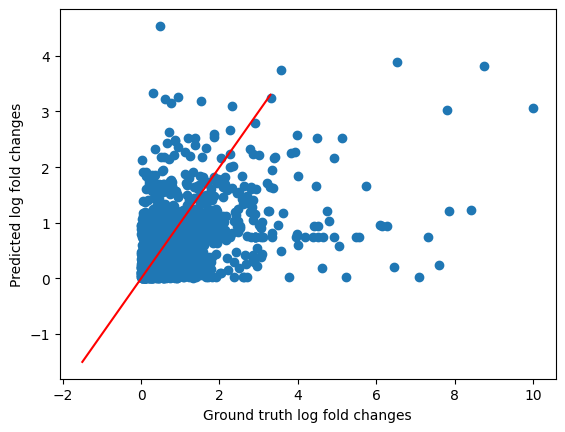

In [123]:
from src.metrics.plots import plot_logfoldchanges

plot_logfoldchanges(np.abs(lfc_real), np.abs(lfc_fake))
from sklearn.linear_model import LinearRegression
model = LinearRegression()

isnan = np.isnan(lfc_real) + np.isnan(lfc_fake)
lfc_real = lfc_real[~isnan]
lfc_fake = lfc_fake[~isnan]


model.fit(lfc_real.reshape(-1, 1), lfc_fake.reshape(-1, 1))
print('Regression slope', model.coef_)

from scipy.stats import spearmanr
mask = [True if abs(lfc_real[i]) > 0.6 else False for i in range(len(lfc_real))]
print('Spearman R', spearmanr(lfc_real, lfc_fake))
from scipy.stats import kendalltau

print('Kendall Tau', kendalltau(lfc_real, lfc_fake))

In [124]:
from src.dataops.pseudobulk import create_pseudobulk
import matplotlib.pyplot as plt
import seaborn as sns

def pseudo_bulk(adata: ad.AnnData, sample_col: str = 'sample', mode: Literal['sum', 'mean'] = 'sum') -> pd.DataFrame:
    pb_adata = create_pseudobulk(adata, sample_col = sample_col, mode = mode)
    pb_df = pd.concat([pb_adata.obs, pb_adata.to_df()], axis=1)
    return pb_df


In [125]:
pb_df_real = pseudo_bulk(adata, sample_col = 'sample_id', mode = 'mean')
# fake_adata.X = 10 * fake_adata.X
pb_df_fake = pseudo_bulk(fake_adata, sample_col = 'sample', mode = 'mean')

Pseudo bulking...
Pseudo bulking...


In [126]:
pb_df_fake

,sample,tissue_unified,disease_colon,psbulk_n_cells,psbulk_counts,A2M,AADAC,ABCA6,ABCA8,ABCA9,...,Z93241.1,ZCCHC12,ZEB2,ZFAND2A,ZFHX4,ZG16B,ZNF165,ZNF385D,ZNF683,ZWINT
SRX9863280,SRX9863280,mucosa of ascending colon,Crohn disease,10845.0,1414657.0,0.000277,0.001014,0.001291,0.000000,0.002766,...,0.049700,0.000092,0.010512,0.281512,0.0,0.259290,0.395666,0.000461,0.001014,0.148732
SRX9863281,SRX9863281,mucosa of ascending colon,Crohn disease,11589.0,1520616.0,0.000518,0.000604,0.002330,0.000173,0.001467,...,0.042627,0.000086,0.013288,0.202261,0.0,0.202174,0.390543,0.000345,0.001467,0.157477
SRX9863282,SRX9863282,mucosa of ascending colon,Crohn disease,12262.0,1608120.0,0.000897,0.000571,0.002528,0.000326,0.003996,...,0.034905,0.000163,0.009052,0.291470,0.0,0.199152,0.325885,0.000245,0.000816,0.185125
SRX9863283,SRX9863283,mucosa of ascending colon,healthy,10808.0,1421902.0,0.000833,0.000740,0.002498,0.000093,0.003886,...,0.029608,0.000093,0.006199,0.158679,0.0,0.231773,0.229552,0.000185,0.000555,0.158956
SRX9863284,SRX9863284,mucosa of ascending colon,healthy,11543.0,1521239.0,0.000433,0.001126,0.001559,0.000000,0.003032,...,0.026683,0.000433,0.005458,0.163995,0.0,0.225245,0.300009,0.000000,0.002166,0.140085
SRX9863285,SRX9863285,mucosa of ascending colon,healthy,8813.0,1146036.0,0.000227,0.001702,0.001475,0.000000,0.002496,...,0.027573,0.000113,0.003744,0.199138,0.0,0.252241,0.289799,0.000113,0.001248,0.120163
SRX9863286,SRX9863286,mucosa of ascending colon,healthy,10896.0,1432028.0,0.001101,0.001193,0.002111,0.000092,0.002478,...,0.024137,0.000000,0.005782,0.172724,0.0,0.185022,0.239262,0.000275,0.000459,0.144824


In [127]:
def melt(pb_df: pd.DataFrame) -> pd.DataFrame:
    # genes_to_keep = ['TRABD2A', 'IGKV3OR2-268', 'IGKV4-1', 'IGKV5-2', 'IGKV3-11']
    genes_to_keep = ['CCL15', 'MT-TV', 'MT-TA', 'MT-TC', 'MT-TE', 'MT-TP']
    pb_df = pb_df[genes_to_keep + ['sample', 'disease_colon']]
    pb_df.rename(columns = {'disease_colon': 'Condition'}, inplace = True)
    pb_df.replace('healthy', 'Healthy', inplace = True)
    # pb_df.replace('ulcerative colitis', 'Ulcerative colitis', inplace = True)
    pb_df_melted = pb_df.melt(id_vars = ['sample', 'Condition'], value_vars = genes_to_keep, var_name = 'Gene', value_name = 'Count')
    return pb_df_melted

def box_plot(pb_df_melted: pd.DataFrame, title: str, loc: Optional[str] = 'upper left', showfliers: bool = True):
    plt.figure()
    sns.boxplot(data = pb_df_melted, y = 'Count', x = 'Gene', hue = 'Condition', palette = sns.light_palette("black", n_colors = 4), legend = loc is not None, showfliers = showfliers)
    sns.stripplot(data = pb_df_melted, legend = False, y = 'Count', x = 'Gene', hue = 'Condition', dodge = True, jitter = 0.15, palette = "viridis", linewidth = 0.5)
    
    if loc is not None:
        plt.legend(loc = loc)
    plt.title(title)
    plt.show()
    plt.close()

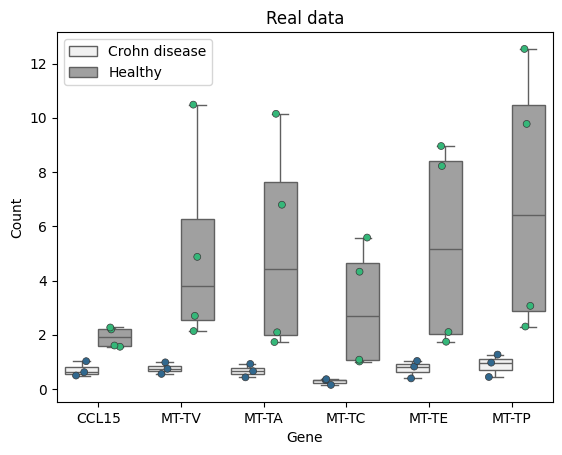

In [128]:
box_plot(melt(pb_df_real), 'Real data')

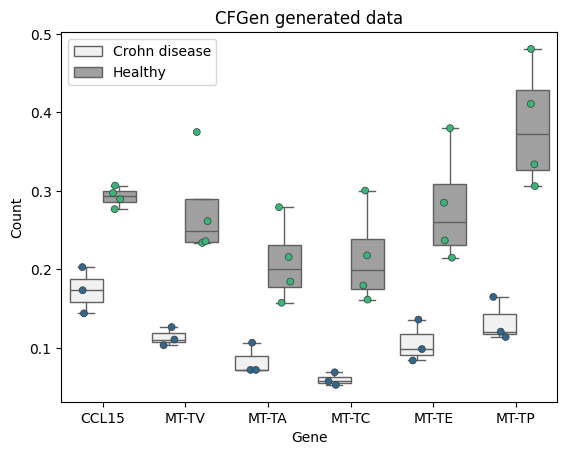

In [ ]:
pb_df_fake_melted = melt(pb_df_fake)
#pb_df_fake_melted.to_csv('pb_df_melted_cfgen.csv', index=False)
#pb_df_fake_melted = pd.read_csv('pb_df_melted_cfgen2.csv', index_col = 0)

box_plot(pb_df_fake_melted, 'Cond-SCVI generated data', showfliers=0)

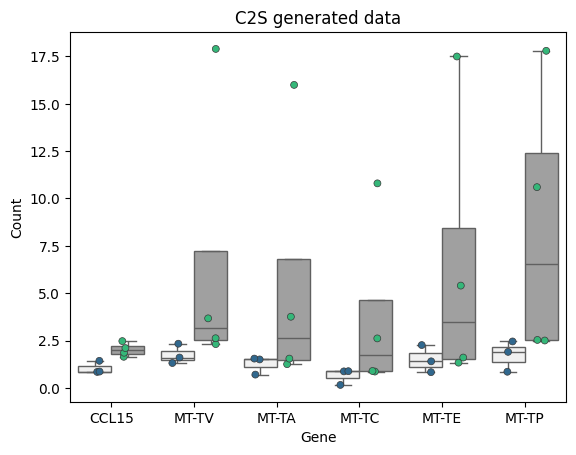

In [130]:
pb_df_c2s_melted = pd.read_csv('pb_df_melted_c2s.csv')
pb_df_c2s = pb_df_c2s_melted.pivot(columns = 'Gene', values = 'Count', index = ['sample', 'Condition'])
box_plot(pb_df_c2s_melted, 'C2S generated data', showfliers = False, loc = None)